# Radial wavefunctions of mixed Yb171 S-states in the FJ and LS coupling scheme

In the notebook `mqdt_exp_qn.ipynb` we looked at the expectation values of $J_{\mathrm{tot}}$ and $F_c$
for the Yb171 $S_{1/2}$ ($F_{\mathrm{tot}}=1/2$) Rydberg series.
For low $\nu$ the states have a well defined $J_{\mathrm{tot}}$ (LS coupling),
for high $\nu$ they have a well defined $F_c$ (FJ coupling).

In between there are states, where both $\langle J_{\mathrm{tot}} \rangle \approx 0.5$ and $\langle F_c \rangle \approx 0.5$
with a large standard deviation, i.e. they are described well by neither coupling scheme.
Here we pick some of these states and look at the radial wavefunctions of their channels,
once in the FJ and once in the LS coupling scheme.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate
from rydstate.angular.utils import get_spectroscopic_letter
from rydstate.rydberg_state import RydbergKet  # noqa: TC001

logging.getLogger("rydstate").setLevel(logging.ERROR)

## Basis

We use the same basis as in `mqdt_exp_qn.ipynb`.

In [2]:
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, l_r=(0, 1), f_tot=(f_tot, f_tot))

basis.filter_states("j_tot", (0, float("inf")))
basis.filter_states("f_c", (0, float("inf")))
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu:.2f}, nu_max = {basis.states[-1].nu:.2f}")

Yb171 basis states: 262
  nu_min = 2.50, nu_max = 129.68


## Selecting the mixed states

We call a state *mixed*, if both $\langle J_{\mathrm{tot}} \rangle$ and $\langle F_c \rangle$ are close to $0.5$.
Since both quantum numbers can only take the values $0$ and $1$ here, this automatically implies a large standard deviation
($\sigma \approx 0.5$).

In [3]:
nu = basis.calc_exp_qn("nu")
exp_j = basis.calc_exp_qn("j_tot")
std_j = basis.calc_std_qn("j_tot")
exp_fc = basis.calc_exp_qn("f_c")
std_fc = basis.calc_std_qn("f_c")

# how far away from 0.5 both expectation values are
mixing_distance = np.abs(exp_j - 0.5) + np.abs(exp_fc - 0.5)
mixed_indices = np.argwhere(mixing_distance < 0.15).flatten()

print(f"{len(mixed_indices)} mixed states found:")
print(f"{'idx':>4} {'nu':>8} {'<J_tot>':>8} {'std':>6} {'<F_c>':>8} {'std':>6}")
for i in mixed_indices:
    print(f"{i:4d} {nu[i]:8.3f} {exp_j[i]:8.3f} {std_j[i]:6.3f} {exp_fc[i]:8.3f} {std_fc[i]:6.3f}")

8 mixed states found:
 idx       nu  <J_tot>    std    <F_c>    std
 153   77.616    0.465  0.499    0.489  0.500
 154   77.751    0.533  0.499    0.510  0.500
 196   98.624    0.455  0.498    0.544  0.498
 197   98.759    0.544  0.498    0.454  0.498
 227  113.609    0.521  0.500    0.438  0.496
 228  113.743    0.479  0.500    0.560  0.496
 250  124.625    0.467  0.499    0.544  0.498
 251  124.757    0.533  0.499    0.454  0.498


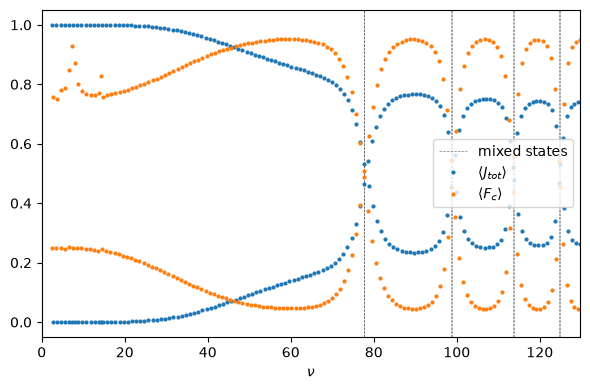

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

for nu_mixed in nu[mixed_indices]:
    ax.axvline(nu_mixed, color="k", lw=0.5, ls="--", alpha=0.5)
ax.plot([], [], "k--", lw=0.5, alpha=0.5, label="mixed states")

ax.plot(nu, exp_j, "C0o", ms=2, label=r"$\langle J_{tot} \rangle$")
ax.plot(nu, exp_fc, "C1o", ms=2, label=r"$\langle F_c \rangle$")

ax.set_xlabel(r"$\nu$")
ax.set_xlim(0, nu[-1])
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()

## Channel wavefunctions in a given coupling scheme

An MQDT state is a superposition of channels $|\Psi\rangle = \sum_i c_i \, |\phi_i\rangle \, u_i(r)$,
where $|\phi_i\rangle$ is the angular (and core) part and $u_i(r)$ the radial wavefunction of channel $i$.
The state is originally given in the FJ coupling scheme, where each channel has a well defined
effective principal quantum number $\nu_i$ and thus a "clean" Coulomb radial wavefunction.

With `RydbergState.to_coupling_scheme` we can rewrite the state in the LS coupling scheme.
The new radial wavefunctions are linear combinations of the FJ channel wavefunctions
and are normalized again, so that the weight $|c_i|^2$ of each channel can be read off from the coefficient.

Below we plot $c_i \, w_i(z)$ with $z = \sqrt{r / a_0}$, so that the different channels are directly comparable in size.

In [5]:
def get_channels(
    state: rydstate.RydbergStateMQDT, coupling_scheme: str, min_weight: float = 1e-3
) -> list[tuple[float, RydbergKet]]:
    """Return the (coefficient, RydbergKet) of the relevant channels of the state in the given coupling scheme."""
    state_cs = state.to_coupling_scheme(coupling_scheme)
    channels = []
    for coeff, ket in state_cs:
        if ket.radial._is_dummy or coeff**2 < min_weight:  # noqa: SLF001
            continue
        channels.append((coeff, ket))
    return channels


def get_channel_label(coeff: float, ket: RydbergKet) -> str:
    """Return a short label for a channel."""
    angular = ket.angular
    if angular.coupling_scheme == "FJ":
        label = rf"$f_c = {angular.f_c:g}$, $\nu_i = {ket.radial.nu:.2f}$"
    elif angular.coupling_scheme == "LS":
        l_str = get_spectroscopic_letter(angular.l_tot).upper()
        label = rf"$^{{{2 * angular.s_tot + 1:g}}}{l_str}_{{{angular.j_tot:g}}}$"
    else:
        label = ket.get_label()
    return rf"{label}: $c_i = {coeff:+.2f}$, $|c_i|^2 = {coeff**2:.2f}$"


def plot_radial_channels(ax: plt.Axes, state: rydstate.RydbergStateMQDT, coupling_scheme: str, lw: float = 0.7) -> None:
    """Plot c_i * w_i(z) for all relevant channels of the state in the given coupling scheme."""
    for coeff, ket in get_channels(state, coupling_scheme):
        ax.plot(ket.radial.z_list, coeff * ket.radial.w_list, label=get_channel_label(coeff, ket), lw=lw)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel(r"$z = \sqrt{r / a_0}$")
    ax.set_ylabel(r"$c_i \, w_i(z)$")
    # make room for the legend above the wavefunctions
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + 0.6 * (y_max - y_min))
    ax.legend(loc="upper left", fontsize=8)

## Mixed states

We take the four most strongly mixed states (smallest distance of both expectation values to $0.5$).

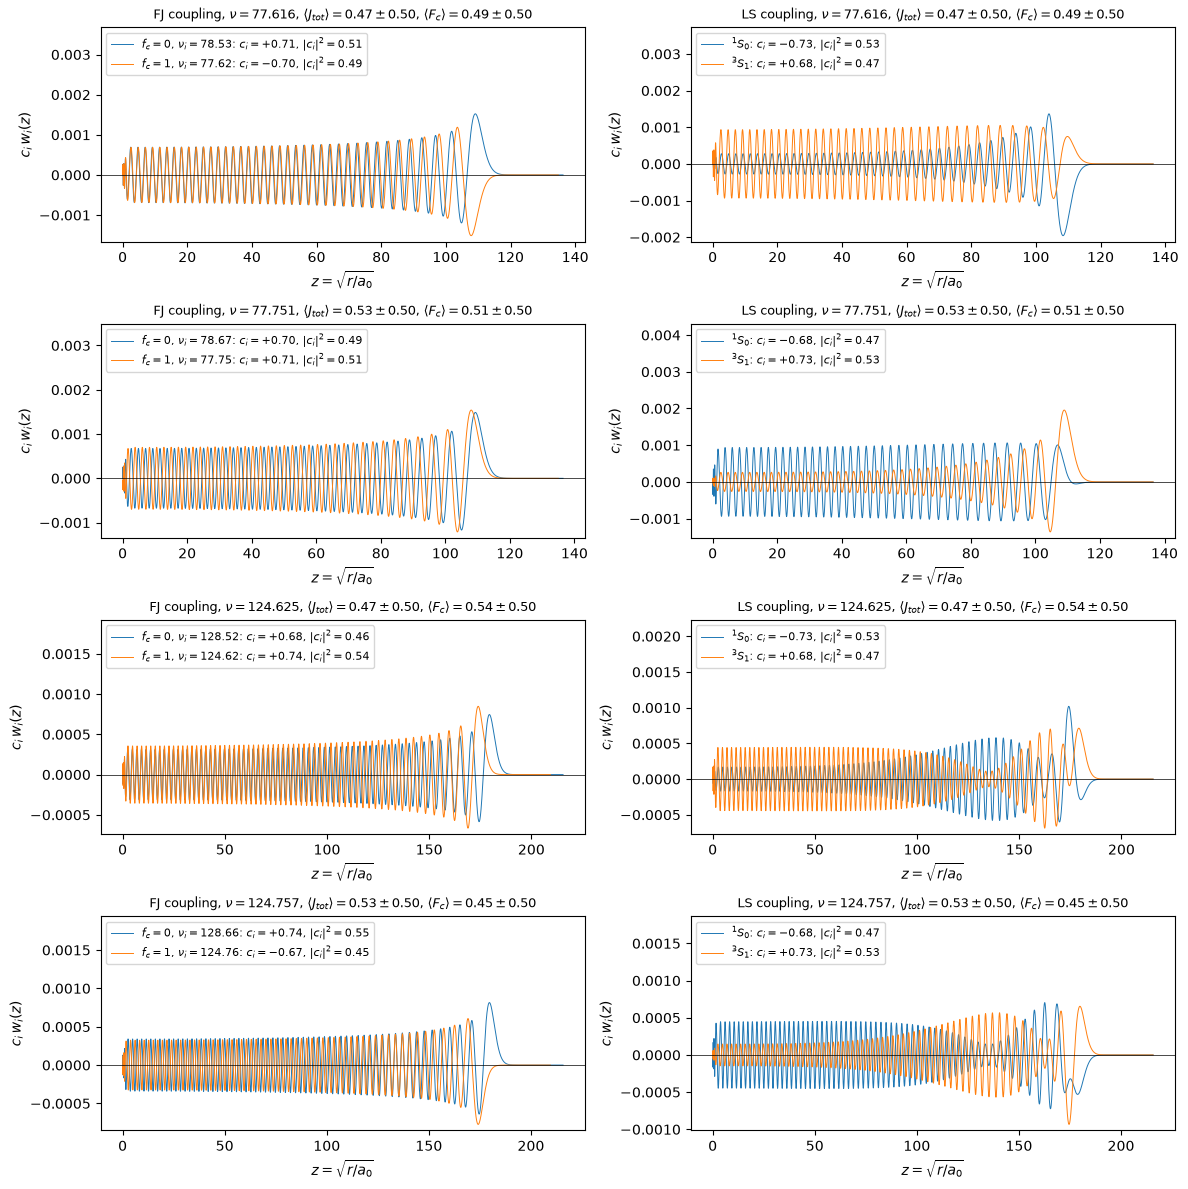

In [6]:
n_plot = 4
plot_indices = sorted(mixed_indices[np.argsort(mixing_distance[mixed_indices])[:n_plot]])

fig, axs = plt.subplots(n_plot, 2, figsize=(12, 3 * n_plot), sharex="row")
for row, i in enumerate(plot_indices):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_radial_channels(ax, state, coupling_scheme)
        ax.set_title(
            rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$, "
            rf"$\langle J_{{tot}} \rangle = {exp_j[i]:.2f} \pm {std_j[i]:.2f}$, "
            rf"$\langle F_c \rangle = {exp_fc[i]:.2f} \pm {std_fc[i]:.2f}$",
            fontsize=9,
        )

fig.tight_layout()
plt.show()

**FJ coupling (left):**
Both channels ($f_c = 0$ and $f_c = 1$) have a clean single-$\nu_i$ Coulomb wavefunction.
The two channels are attached to the two hyperfine thresholds of the ion core, so their $\nu_i$ differ.
The difference $\Delta \nu_i \approx \nu^3 \, \Delta E_{\mathrm{hfs}} / (2 \, \mathrm{Ry})$ grows with $\nu$:
it is about $1$ for $\nu \approx 78$ and about $4$ for $\nu \approx 125$,
i.e. the two wavefunctions have a different number of nodes.
The weights are close to $50/50$, so $F_c$ is not a good quantum number, although each radial wavefunction on its own is simple.

**LS coupling (right):**
The $^1S_0$ ($J_{\mathrm{tot}} = 0$) and $^3S_1$ ($J_{\mathrm{tot}} = 1$) radial wavefunctions are (up to Clebsch-Gordan coefficients)
the sum and the difference of the two FJ channel wavefunctions.
Since the FJ wavefunctions are nearly in phase at short distances and drift out of phase towards the outer turning point,
the LS wavefunctions get a beating envelope (with more beats the larger $\Delta \nu_i$ is):
where one of them is large the other one is small and vice versa.
They do not have a well defined $\nu_i$ (note the `nu=None` of the radial wavefunction) and the weights are again close to $50/50$.

So for these states there is no coupling scheme, in which the state is dominated by a single channel with a simple radial wavefunction.

## Comparison to states, which are well described by one coupling scheme

For comparison we show a low-$\nu$ state with well defined $J_{\mathrm{tot}}$ (LS coupling)
and a high-$\nu$ state with well defined $F_c$ (FJ coupling).

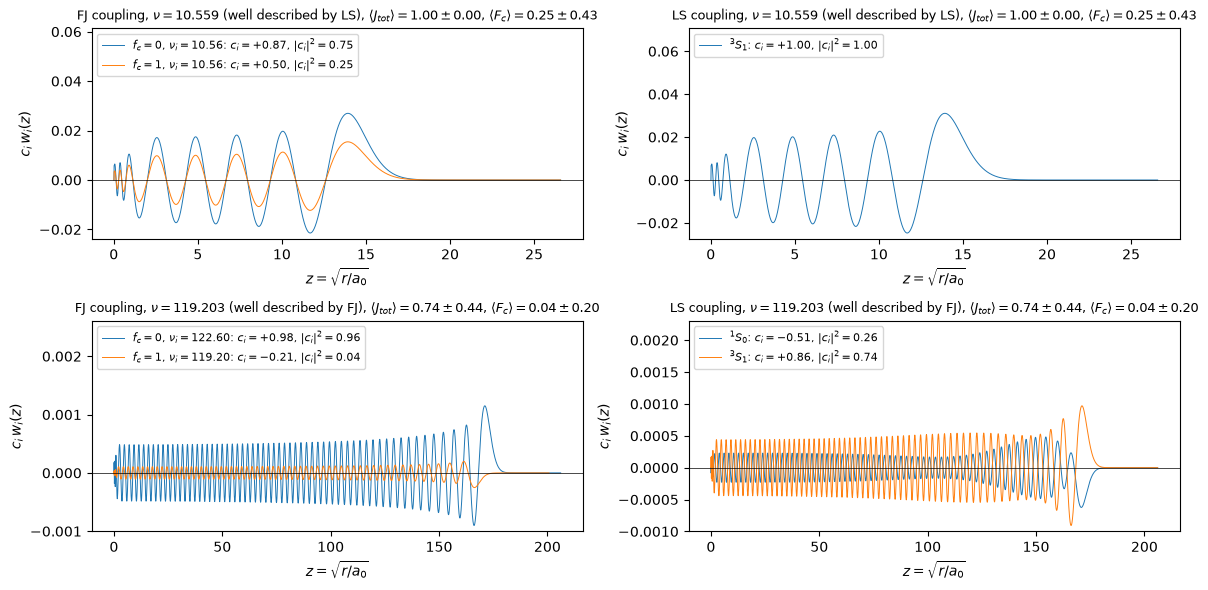

In [7]:
mask = nu > 10  # skip low lying states with strong perturber admixture
i_ls = np.argwhere(mask).flatten()[np.argmin(std_j[mask])]
i_fj = np.argwhere(mask).flatten()[np.argmin(std_fc[mask])]

fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex="row")
for row, (i, description) in enumerate([(i_ls, "well described by LS"), (i_fj, "well described by FJ")]):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_radial_channels(ax, state, coupling_scheme)
        ax.set_title(
            rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$ ({description}), "
            rf"$\langle J_{{tot}} \rangle = {exp_j[i]:.2f} \pm {std_j[i]:.2f}$, "
            rf"$\langle F_c \rangle = {exp_fc[i]:.2f} \pm {std_fc[i]:.2f}$",
            fontsize=9,
        )

fig.tight_layout()
plt.show()

For the low-$\nu$ state the two FJ channels have almost the same $\nu_i$ (the hyperfine splitting of the core is small
compared to the level spacing), so their radial wavefunctions are nearly identical.
Their difference vanishes and the state is a pure $^3S_1$ state in LS coupling.

For the high-$\nu$ state the level spacing is smaller than the hyperfine splitting of the core,
the two FJ channel wavefunctions are very different and the state is dominated by a single FJ channel.
In LS coupling both channels carry a large weight and their radial wavefunctions show a strong beating.